### 1. Importing all the essential libraries

In [ ]:
# Import standard libraries for string manipulation, regex, and file handling
import string 
import re
import codecs

# Import core data science libraries
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import scikit-learn modules for feature extraction and modeling
from sklearn import feature_extraction
from sklearn import linear_model
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import pipeline
from sklearn.model_selection import train_test_split
from sklearn import metrics

# Import itertools for confusion matrix plotting
import itertools

     ---------------------------------------- 0.0/44.0 kB ? eta -:--:--
     ---------------------------------------- 44.0/44.0 kB 2.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.0 MB ? eta -:--:--
   ---------------------------------------- 0.1/12.0 MB 3.3 MB/s eta 0:00:04
    --------------------------------------- 0.3/12.0 MB 2.6 MB/s eta 0:00:05
   - -------------------------------------- 0.4/12.0 MB 3.3 MB/s eta 0:00:04
   -- ------------------------------------- 0.6/12.0 MB 3.6 MB/s eta 0:00:04
   -- ------------------------------------- 0.9/12.0 MB 3.7 MB/s eta 0:00:04
   --- ------------------------------------ 1.1/12.0 MB 4.0 MB/s eta 0:00:03
   ---- ----------------------------------- 1.4/12.0 MB 4.3 MB/s eta 0:00:03
   ----- ---------------------------------- 1.7/12.0 MB 4.6 MB/s eta 0:00:03
   ------ --------------------------------- 2.1/12.0 MB 4.9 MB/s eta 0:00:03
   -------- ------------------------------- 2.5/12.0 MB 5.3 MB/s eta 0:00:02
   -----

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.32.0 requires packaging<24,>=16.8, but you have packaging 24.2 which is incompatible.


### 2. Loading the data

In [ ]:
# Load the raw English dataset from a file
with open(r"C:\Users\apoor\Desktop\NLP DATASET\bg-en\europarl-v7.bg-en.en", encoding="utf-8") as f:
    lines = f.readlines()

# Create a pandas DataFrame from the loaded lines
english_df = pd.DataFrame([line.strip() for line in lines], columns=["English"])

In [ ]:
# Display the first few rows of the English DataFrame
english_df.head()

,English
0,Membership of Parliament: see Minutes
1,Approval of Minutes of previous sitting: see M...
2,Membership of Parliament: see Minutes
3,Verification of credentials: see Minutes
4,Documents received: see Minutes


In [ ]:
# Load the raw German dataset from a file
with open(r"C:\Users\apoor\Desktop\NLP DATASET\de-en\europarl-v7.de-en.de", encoding="utf-8") as f:
    lines = f.readlines()

# Create a DataFrame for the German data
german_df = pd.DataFrame([line.strip() for line in lines], columns=["German"])
# Display the first few rows
german_df.head()

,German
0,Wiederaufnahme der Sitzungsperiode
1,"Ich erkläre die am Freitag, dem 17. Dezember u..."
2,"Wie Sie feststellen konnten, ist der gefürchte..."
3,Im Parlament besteht der Wunsch nach einer Aus...
4,Heute möchte ich Sie bitten - das ist auch der...


In [ ]:
# Load the raw French dataset from a file
with open(r"C:\Users\apoor\Desktop\NLP DATASET\fr-en\europarl-v7.fr-en.fr", encoding="utf-8") as f:
    lines = f.readlines()
# Create a DataFrame for the French data
french_df = pd.DataFrame([line.strip() for line in lines], columns=["French"])
# Display the first few rows
french_df.head()

,French
0,Reprise de la session
1,Je déclare reprise la session du Parlement eur...
2,"Comme vous avez pu le constater, le grand ""bog..."
3,Vous avez souhaité un débat à ce sujet dans le...
4,"En attendant, je souhaiterais, comme un certai..."


In [ ]:
# Load the raw Spanish dataset from a file
with open(r"C:\Users\apoor\Desktop\NLP DATASET\es-en\europarl-v7.es-en.es", encoding="utf-8") as f:
    lines = f.readlines()
# Create a DataFrame for the Spanish data
spanish_df = pd.DataFrame([line.strip() for line in lines], columns=["Spanish"])
# Display the first few rows
spanish_df.head()

,Spanish
0,Reanudación del período de sesiones
1,Declaro reanudado el período de sesiones del P...
2,"Como todos han podido comprobar, el gran ""efec..."
3,Sus Señorías han solicitado un debate sobre el...
4,"A la espera de que se produzca, de acuerdo con..."


In [ ]:
# Load the raw Bulgarian dataset from a file
with open(r"C:\Users\apoor\Desktop\NLP DATASET\bg-en\europarl-v7.bg-en.bg", encoding="utf-8") as f:
    lines = f.readlines()
# Create a DataFrame for the Bulgarian data
bulgarian_df = pd.DataFrame([line.strip() for line in lines], columns=["Bulgarian"])
# Display the first few rows
bulgarian_df.head()

,Bulgarian
0,Състав на Парламента: вж. протоколи
1,Одобряване на протокола от предишното заседани...
2,Състав на Парламента: вж. протоколи
3,Проверка на пълномощията: вж. протоколи
4,Внасяне на документи: вж. протоколи


In [ ]:
# Load the raw Czech dataset from a file
with open(r"C:\Users\apoor\Desktop\NLP DATASET\cs-en\europarl-v7.cs-en.cs", encoding="utf-8") as f:
    lines = f.readlines()
# Create a DataFrame for the Czech data
czech_df = pd.DataFrame([line.strip() for line in lines], columns=["Czech"])
# Display the first few rows
czech_df.head()

,Czech
0,Následný postup na základě usnesení Parlamentu...
1,Předložení dokumentů: viz zápis
2,Písemná prohlášení (článek 116 jednacího řádu)...
3,Texty smluv dodané Radou: viz zápis
4,Složení Parlamentu: viz zápis


In [ ]:
# Load the raw Danish dataset from a file
with open(r"C:\Users\apoor\Desktop\NLP DATASET\da-en\europarl-v7.da-en.da", encoding="utf-8") as f:
    lines = f.readlines()
# Create a DataFrame for the Danish data
danish_df = pd.DataFrame([line.strip() for line in lines], columns=["Danish"])
# Display the first few rows
danish_df.head()

,Danish
0,Genoptagelse af sessionen
1,"Jeg erklærer Europa-Parlamentets session, der ..."
2,"Som De kan se, indfandt det store ""år 2000-pro..."
3,De har udtrykt ønske om en debat om dette emne...
4,I mellemtiden ønsker jeg - som også en del kol...


In [ ]:
# Load the raw Finnish dataset from a file
with open(r"C:\Users\apoor\Desktop\NLP DATASET\fi-en\europarl-v7.fi-en.fi", encoding="utf-8") as f:
    lines = f.readlines()
# Create a DataFrame for the Finnish data
finnish_df = pd.DataFrame([line.strip() for line in lines], columns=["Finnish"])
# Display the first few rows
finnish_df.head()

,Finnish
0,Istuntokauden uudelleenavaaminen
1,Julistan perjantaina joulukuun 17. päivänä kes...
2,"Kuten olette varmaan saattaneet huomata, vuode..."
3,"Te olette esittäneet toiveen, että tästä asias..."
4,"Sillä välin toivoisin, kuten useampi kollega o..."


In [ ]:
# Load the raw Hungarian dataset from a file
with open(r"C:\Users\apoor\Desktop\NLP DATASET\hu-en\europarl-v7.hu-en.hu", encoding="utf-8") as f:
    lines = f.readlines()
# Create a DataFrame for the Hungarian data
hungarian_df = pd.DataFrame([line.strip() for line in lines], columns=["Hungarian"])
# Display the first few rows
hungarian_df.head()

,Hungarian
0,A Parlament állásfoglalásaival kapcsolatos tov...
1,Dokumentumok benyújtása: lásd a jegyzőkönyvet
2,Írásbeli nyilatkozatok (az Eljárási Szabályzat...
3,A megállapodások szövegeinek Tanács általi elő...
4,A Parlament tagjai: lásd a jegyzőkönyvet


In [ ]:
# Load the raw Latvian dataset from a file
with open(r"C:\Users\apoor\Desktop\NLP DATASET\lv-en\europarl-v7.lv-en.lv", encoding="utf-8") as f:
    lines = f.readlines()
# Create a DataFrame for the Latvian data
latvian_df = pd.DataFrame([line.strip() for line in lines], columns=["Latvian"])
# Display the first few rows
latvian_df.head()

,Latvian
0,Saistībā ar Parlamenta rezolūcijām veiktie pas...
1,Dokumentu iesniegšana (sk. protokolu)
2,Rakstiskas deklarācijas (Reglamenta 116. pants...
3,Padomes nosūtītie nolīgumu teksti (sk. protokolu)
4,Parlamenta sastāvs (sk. protokolu)


In [ ]:
# Load the raw Dutch dataset from a file
with open(r"C:\Users\apoor\Desktop\NLP DATASET\nl-en\europarl-v7.nl-en.nl", encoding="utf-8") as f:
    lines = f.readlines()
# Create a DataFrame for the Dutch data
dutch_df = pd.DataFrame([line.strip() for line in lines], columns=["Dutch"])
# Display the first few rows
dutch_df.head()

,Dutch
0,Hervatting van de zitting
1,Ik verklaar de zitting van het Europees Parlem...
2,"Zoals u heeft kunnen constateren, is de grote ..."
3,U heeft aangegeven dat u deze vergaderperiode ...
4,Nu wil ik graag op verzoek van een aantal coll...


In [ ]:
# Load the raw Portuguese dataset from a file
with open(r"C:\Users\apoor\Desktop\NLP DATASET\pt-en\europarl-v7.pt-en.pt", encoding="utf-8") as f:
    lines = f.readlines()
# Create a DataFrame for the Portuguese data
portuguese_df = pd.DataFrame([line.strip() for line in lines], columns=["Portuguese"])
# Display the first few rows
portuguese_df.head()

,Polish
0,Działania podjęte w wyniku rezolucji Parlament...
1,Składanie dokumentów: patrz protokół
2,Oświadczenia pisemne (art. 116 Regulaminu): pa...
3,Teksty porozumień przekazane przez Radę: patrz...
4,Skład Parlamentu: patrz protokół


In [ ]:
# Load the raw Portuguese dataset from a file
with open(r"C:\Users\apoor\Desktop\NLP DATASET\pt-en\europarl-v7.pt-en.pt", encoding="utf-8") as f:
    lines = f.readlines()
# Create a DataFrame for the Portuguese data
portuguese_df = pd.DataFrame([line.strip() for line in lines], columns=["Portuguese"])
# Display the first few rows
portuguese_df.head()

,Portuguese
0,Reinício da sessão
1,Declaro reaberta a sessão do Parlamento Europe...
2,"Como puderam constatar, o grande ""bug do ano 2..."
3,Os senhores manifestaram o desejo de se proced...
4,"Entretanto, gostaria - como também me foi pedi..."


In [ ]:
# Load the raw Romanian dataset from a file
with open(r"C:\Users\apoor\Desktop\NLP DATASET\ro-en\europarl-v7.ro-en.ro", encoding="utf-8") as f:
    lines = f.readlines()
# Create a DataFrame for the Romanian data
romanian_df = pd.DataFrame([line.strip() for line in lines], columns=["Romanian"])
# Display the first few rows
romanian_df.head()

,Romanian
0,Componenţa Parlamentului: a se vedea procesul-...
1,Aprobarea procesului-verbal al şedinţei preced...
2,Componenţa Parlamentului: a se vedea procesul-...
3,Verificarea prerogativelor: a se vedea procesu...
4,Depunere de documente: a se vedea procesul-verbal


In [ ]:
# Load the raw Slovenian dataset from a file
with open(r"C:\Users\apoor\Desktop\NLP DATASET\sl-en\europarl-v7.sl-en.sl", encoding="utf-8") as f:
    lines = f.readlines()
# Create a DataFrame for the Slovenian data
slovenian_df = pd.DataFrame([line.strip() for line in lines], columns=["Slovenian"])
# Display the first few rows
slovenian_df.head()

,Slovenian
0,Nadaljnje obravnavanje resolucij Parlamenta: g...
1,Predložitev dokumentov: glej zapisnik
2,Pisne izjave (člen 116): glej zapisnik
3,Posredovanje besedil sporazumov s strani Sveta...
4,Sestava Parlamenta: glej zapisnik


In [ ]:
# Load the raw Swedish dataset from a file
with open(r"C:\Users\apoor\Desktop\NLP DATASET\sv-en\europarl-v7.sv-en.sv", encoding="utf-8") as f:
    lines = f.readlines()
# Create a DataFrame for the Swedish data
swedish_df = pd.DataFrame([line.strip() for line in lines], columns=["Swedish"])
# Display the first few rows
swedish_df.head()

,Swedish
0,Återupptagande av sessionen
1,Jag förklarar Europaparlamentets session återu...
2,"Som ni kunnat konstatera ägde ""den stora år 20..."
3,Ni har begärt en debatt i ämnet under sammantr...
4,"Till dess vill jag att vi, som ett antal kolle..."


### 3. Data Preprocessing

In [ ]:
# Print all punctuation characters for verification
for char in string.punctuation:
    print(char, end = ' ')

# Create a translation table to remove all punctuation
translate_table = dict((ord(char), None) for char in string.punctuation)

! " # $ % & ' ( ) * + , - . / : ; < = > ? @ [ \ ] ^ _ ` { | } ~ 

In [ ]:
# Cleaning the data for english dataset

data_eng = []
lang_eng = []

for i, line in english_df.iterrows():
    line = line['English']
    if len(line) !=0:
        line = line.lower()
        line = re.sub(r"\d+", "", line)
        line = line.translate(translate_table)
        data_eng.append(line)
        lang_eng.append("English")

In [ ]:
# Cleaning the data for german dataset

data_ger = []
lang_ger = []

for i, line in german_df.iterrows():
    line = line['German']
    if len(line) !=0:
        line = line.lower()
        line = re.sub(r"\d+", "", line)
        line = line.translate(translate_table)
        data_ger.append(line)
        lang_ger.append("German")

In [ ]:
# Cleaning the data for french dataset

data_fre = []
lang_fre = []

for i, line in french_df.iterrows():
    line = line['French']
    if len(line) !=0:
        line = line.lower()
        line = re.sub(r"\d+", "", line)
        line = line.translate(translate_table)
        data_fre.append(line)
        lang_fre.append("French")

In [ ]:
# Cleaning the data for spanish dataset

data_esp = []
lang_esp = []

for i, line in spanish_df.iterrows():
    line = line['Spanish']
    if len(line) !=0:
        line = line.lower()
        line = re.sub(r"\d+", "", line)
        line = line.translate(translate_table)
        data_esp.append(line)
        lang_esp.append("Spanish")

In [24]:
# Cleaning the data for Bulgarian dataset

data_bul = []
lang_bul = []

for i, line in bulgarian_df.iterrows():
    line = line['Bulgarian']
    if len(line) !=0:
        line = line.lower()
        line = re.sub(r"\d+", "", line)
        line = line.translate(translate_table)
        data_bul.append(line)
        lang_bul.append("Bulgarian")

In [25]:
# Cleaning the data for Czech dataset

data_czech = []
lang_czech = []

for i, line in czech_df.iterrows():
    line = line['Czech']
    if len(line) !=0:
        line = line.lower()
        line = re.sub(r"\d+", "", line)
        line = line.translate(translate_table)
        data_czech.append(line)
        lang_czech.append("Czech")

In [26]:
# Cleaning the data for Danish dataset

data_dan = []
lang_dan = []

for i, line in danish_df.iterrows():
    line = line['Danish']
    if len(line) !=0:
        line = line.lower()
        line = re.sub(r"\d+", "", line)
        line = line.translate(translate_table)
        data_dan.append(line)
        lang_dan.append("Danish")

In [27]:
# Cleaning the data for finnish dataset

data_fin = []
lang_fin = []

for i, line in finnish_df.iterrows():
    line = line['Finnish']
    if len(line) !=0:
        line = line.lower()
        line = re.sub(r"\d+", "", line)
        line = line.translate(translate_table)
        data_fin.append(line)
        lang_fin.append("Finnish")

In [28]:
# Cleaning the data for Hugarian dataset

data_hung = []
lang_hung = []

for i, line in hungarian_df.iterrows():
    line = line['Hungarian']
    if len(line) !=0:
        line = line.lower()
        line = re.sub(r"\d+", "", line)
        line = line.translate(translate_table)
        data_hung.append(line)
        lang_hung.append("Hungarian")

In [29]:
# Cleaning the data for Latvian dataset

data_lat = []
lang_lat = []

for i, line in latvian_df.iterrows():
    line = line['Latvian']
    if len(line) !=0:
        line = line.lower()
        line = re.sub(r"\d+", "", line)
        line = line.translate(translate_table)
        data_lat.append(line)
        lang_lat.append("Latvian")

In [30]:
# Cleaning the data for Dutch dataset

data_dutch = []
lang_dutch = []

for i, line in dutch_df.iterrows():
    line = line['Dutch']
    if len(line) !=0:
        line = line.lower()
        line = re.sub(r"\d+", "", line)
        line = line.translate(translate_table)
        data_dutch.append(line)
        lang_dutch.append("Dutch")

In [31]:
# Cleaning the data for Polish dataset

data_pol = []
lang_pol = []

for i, line in polish_df.iterrows():
    line = line['Polish']
    if len(line) !=0:
        line = line.lower()
        line = re.sub(r"\d+", "", line)
        line = line.translate(translate_table)
        data_pol.append(line)
        lang_pol.append("Polish")

In [32]:
# Cleaning the data for Portuguese dataset

data_port = []
lang_port = []

for i, line in portuguese_df.iterrows():
    line = line['Portuguese']
    if len(line) !=0:
        line = line.lower()
        line = re.sub(r"\d+", "", line)
        line = line.translate(translate_table)
        data_port.append(line)
        lang_port.append("Portuguese")

In [34]:
# Cleaning the data for Romanian dataset

data_rom = []
lang_rom = []

for i, line in romanian_df.iterrows():
    line = line['Romanian']
    if len(line) !=0:
        line = line.lower()
        line = re.sub(r"\d+", "", line)
        line = line.translate(translate_table)
        data_rom.append(line)
        lang_rom.append("Romanian")

In [35]:
# Cleaning the data for Slovenian dataset

data_slo = []
lang_slo = []

for i, line in slovenian_df.iterrows():
    line = line['Slovenian']
    if len(line) !=0:
        line = line.lower()
        line = re.sub(r"\d+", "", line)
        line = line.translate(translate_table)
        data_slo.append(line)
        lang_slo.append("Slovenian")

In [ ]:
# Install the pyarrow library, required for saving/loading Parquet files
pip install pyarrow

Note: you may need to restart the kernel to use updated packages.


In [ ]:
print("Combining all 15 language lists into one DataFrame...")

# Combine all the preprocessed text and label lists into a single DataFrame
df = pd.DataFrame({
    "Text" : data_eng + data_ger + data_fre + data_esp + data_bul + 
             data_czech + data_dan + data_fin + data_hung + data_lat + 
             data_dutch + data_port + data_pol + data_rom + data_slo,
    
    "Language" : lang_eng + lang_ger + lang_fre + lang_esp + lang_bul + 
                 lang_czech + lang_dan + lang_fin + lang_hung + lang_lat + 
                 lang_dutch + lang_port + lang_pol + lang_rom + lang_slo
})

# Print information about the newly created DataFrame
print(f"DataFrame created successfully with {len(df)} rows.")
print(df.head())
print("\nLanguage value counts:")
print(df['Language'].value_counts())

# Save the combined DataFrame to a Parquet file for efficient storage and loading
print("\nSaving clean DataFrame to 'clean_europarl_data.parquet'...")
try:
    df.to_parquet('clean_europarl_data.parquet')
    print("Done! File 'clean_europarl_data.parquet' is saved.")
except Exception as e:
    print(f"Error saving file: {e}")
    print("Please make sure you have 'pyarrow' installed (pip install pyarrow)")

Combining all 16 language lists into one DataFrame...
DataFrame created successfully with 18102929 rows.
                                                Text Language
0               membership of parliament see minutes  English
1  approval of minutes of previous sitting see mi...  English
2               membership of parliament see minutes  English
3            verification of credentials see minutes  English
4                     documents received see minutes  English

Language value counts:
Language
French        2004791
Dutch         1994383
Danish        1965920
Spanish       1962213
Portuguese    1957517
Finnish       1923010
German        1917286
Czech          646526
Latvian        637526
Polish         632416
Hungarian      624837
Slovenian      623445
Bulgarian      406883
English        406879
Romanian       399297
Name: count, dtype: int64

Saving clean DataFrame to 'clean_europarl_data.parquet'...
✅ Done! File 'clean_europarl_data.parquet' is saved.


### 4. Transforming the data into a single dataset

In [ ]:
# This cell re-creates the DataFrame, which was already done in the previous cell.
# It is included here to match the notebook structure.
df = pd.DataFrame({
    "Text" : data_eng+data_ger+data_fre+data_esp+data_bul+data_czech+data_dan+data_fin+data_hung+data_lat+data_dutch+data_port+data_pol+data_rom+data_slo,
    "Language" : lang_eng+lang_ger+lang_fre+lang_esp+lang_bul+lang_czech+lang_dan+lang_fin+lang_hung+lang_lat+lang_dutch+lang_port+lang_pol+lang_rom+lang_slo
})

# Print the shape (rows, columns) of the final DataFrame
print(df.shape)

(18102929, 2)


In [ ]:
# Display the first few rows of the final DataFrame
df.head()

,Text,Language
0,membership of parliament see minutes,English
1,approval of minutes of previous sitting see mi...,English
2,membership of parliament see minutes,English
3,verification of credentials see minutes,English
4,documents received see minutes,English


In [ ]:
# Display the last few rows of the final DataFrame
df.tail()

,Text,Language
18102924,sestava odborov in delegacij gl zapisnik,Slovenian
18102925,dnevni red naslednje seje gl zapisnik,Slovenian
18102926,zaključek seje,Slovenian
18102927,the sitting closed at,Slovenian
18102928,,Slovenian


In [ ]:
# Show the distribution of text samples per language
df['Language'].value_counts()

Language
French        2004791
Dutch         1994383
Danish        1965920
Spanish       1962213
Portuguese    1957517
Finnish       1923010
German        1917286
Czech          646526
Latvian        637526
Polish         632416
Hungarian      624837
Slovenian      623445
Bulgarian      406883
English        406879
Romanian       399297
Name: count, dtype: int64

<Axes: xlabel='Language', ylabel='count'>

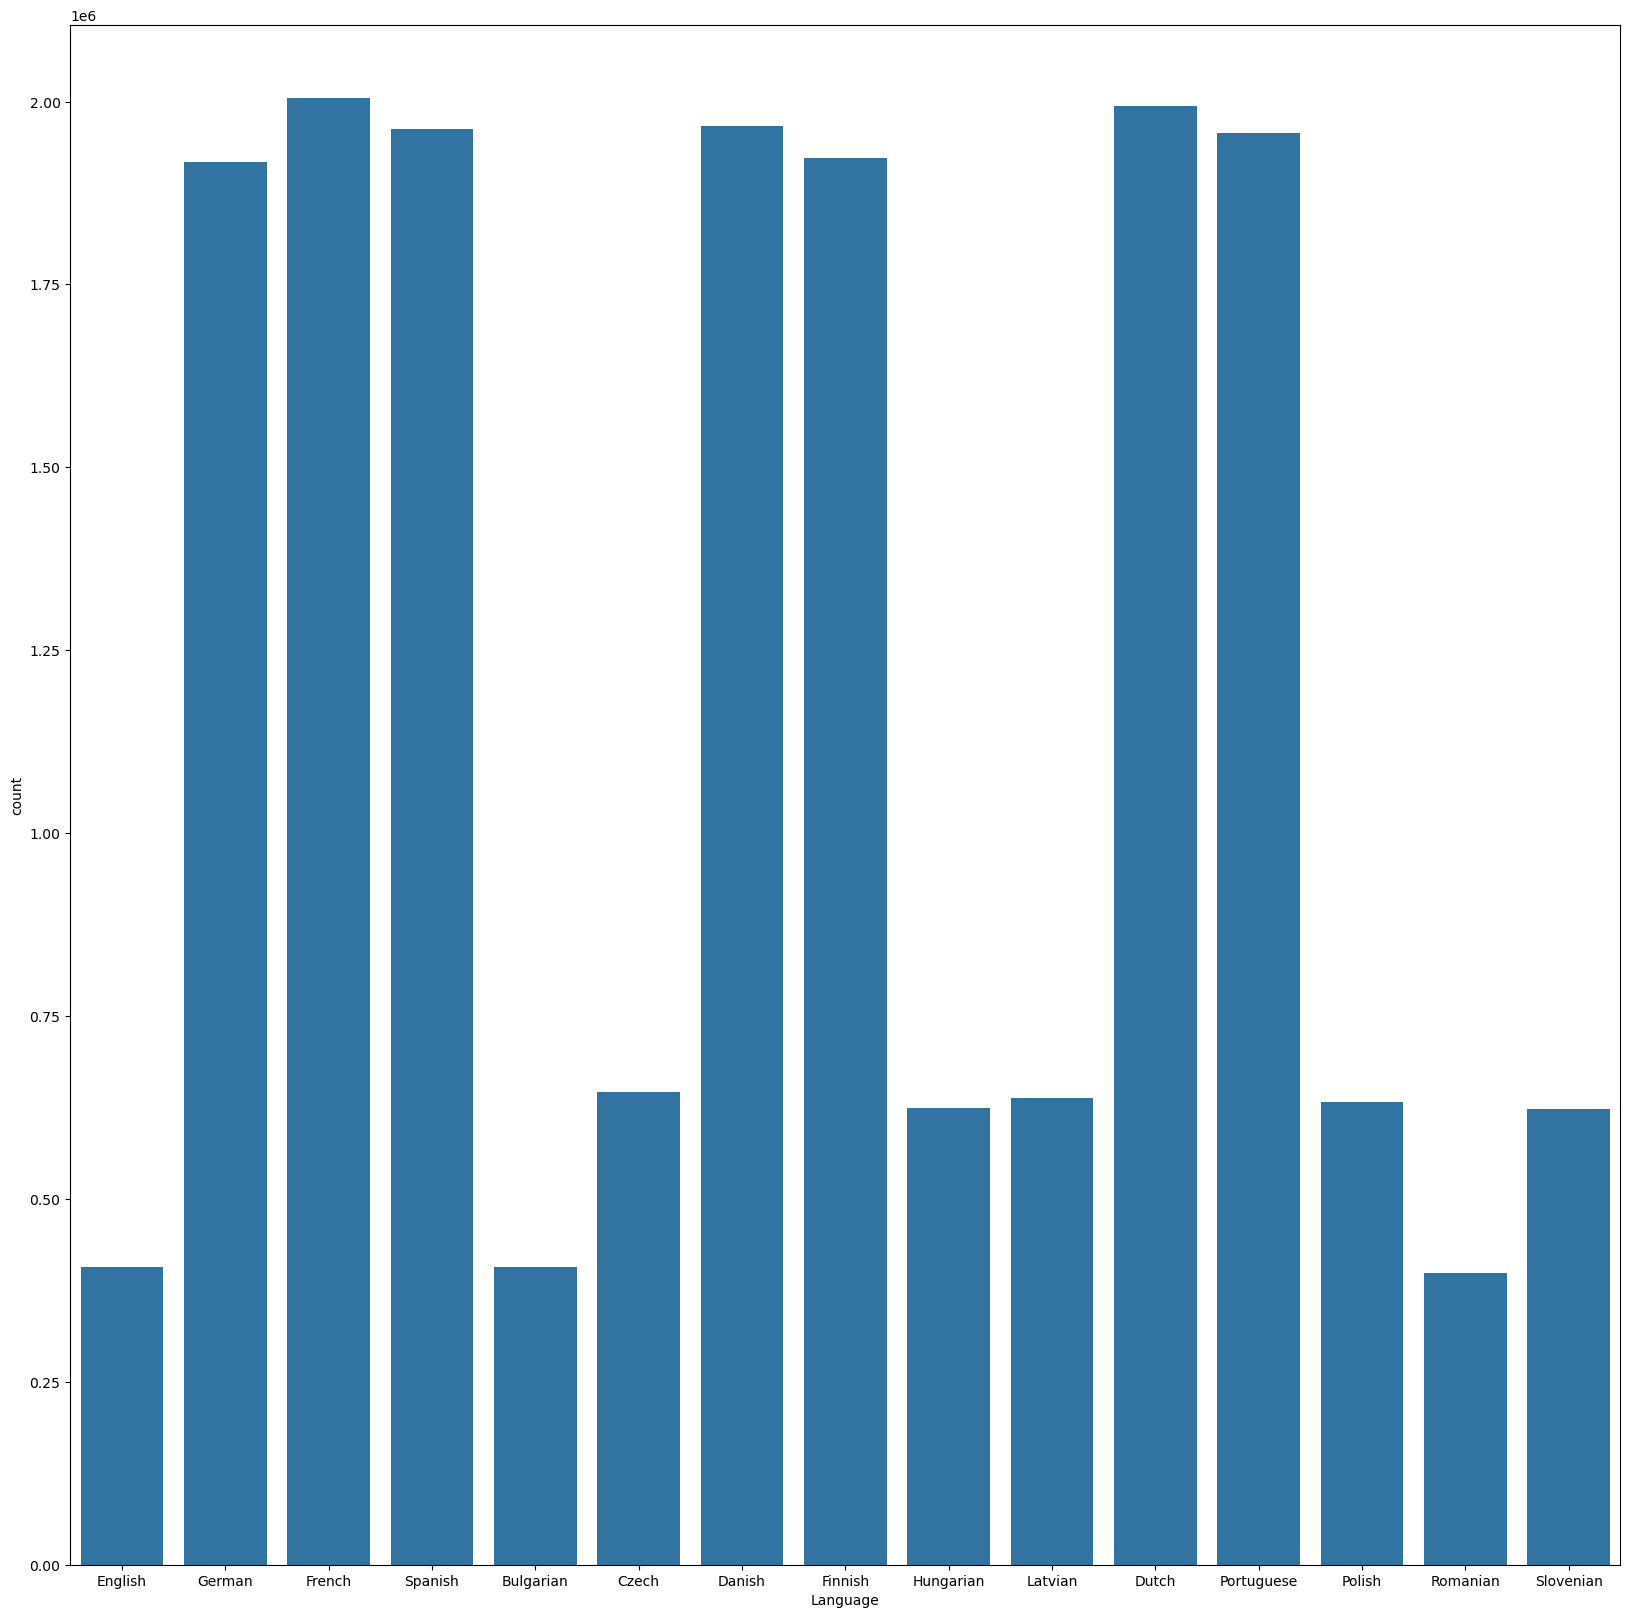

In [ ]:
# Create a large figure for the plot
plt.figure(figsize=(20,20))
# Plot the language distribution as a bar chart
sns.countplot(x = df['Language'], data=df)

Loading clean data from Parquet file...
✅ Clean data loaded! (18102929 rows)

Splitting the dataset...
Total samples: 18102929
Training samples: 14482343
Testing samples: 3620586

Running quick test with MultinomialNB on a small sample...
✅ MultinomialNB quick test accuracy: 98.90%

Training main LogisticRegression model...
Fitting pipeline on the FULL training set... (This will take time)
[LibLinear]✅ Main model training complete.

Evaluating main model on the test set...
✅ LogisticRegression Accuracy (FULL test set): 97.07 %

Calculating and plotting confusion matrix...
✅ Confusion matrix saved to 'confusion_matrix_full_model.png'

Saving the main (pipe_lr) model to 'language_detection_model.joblib'...
✅ Model saved successfully!


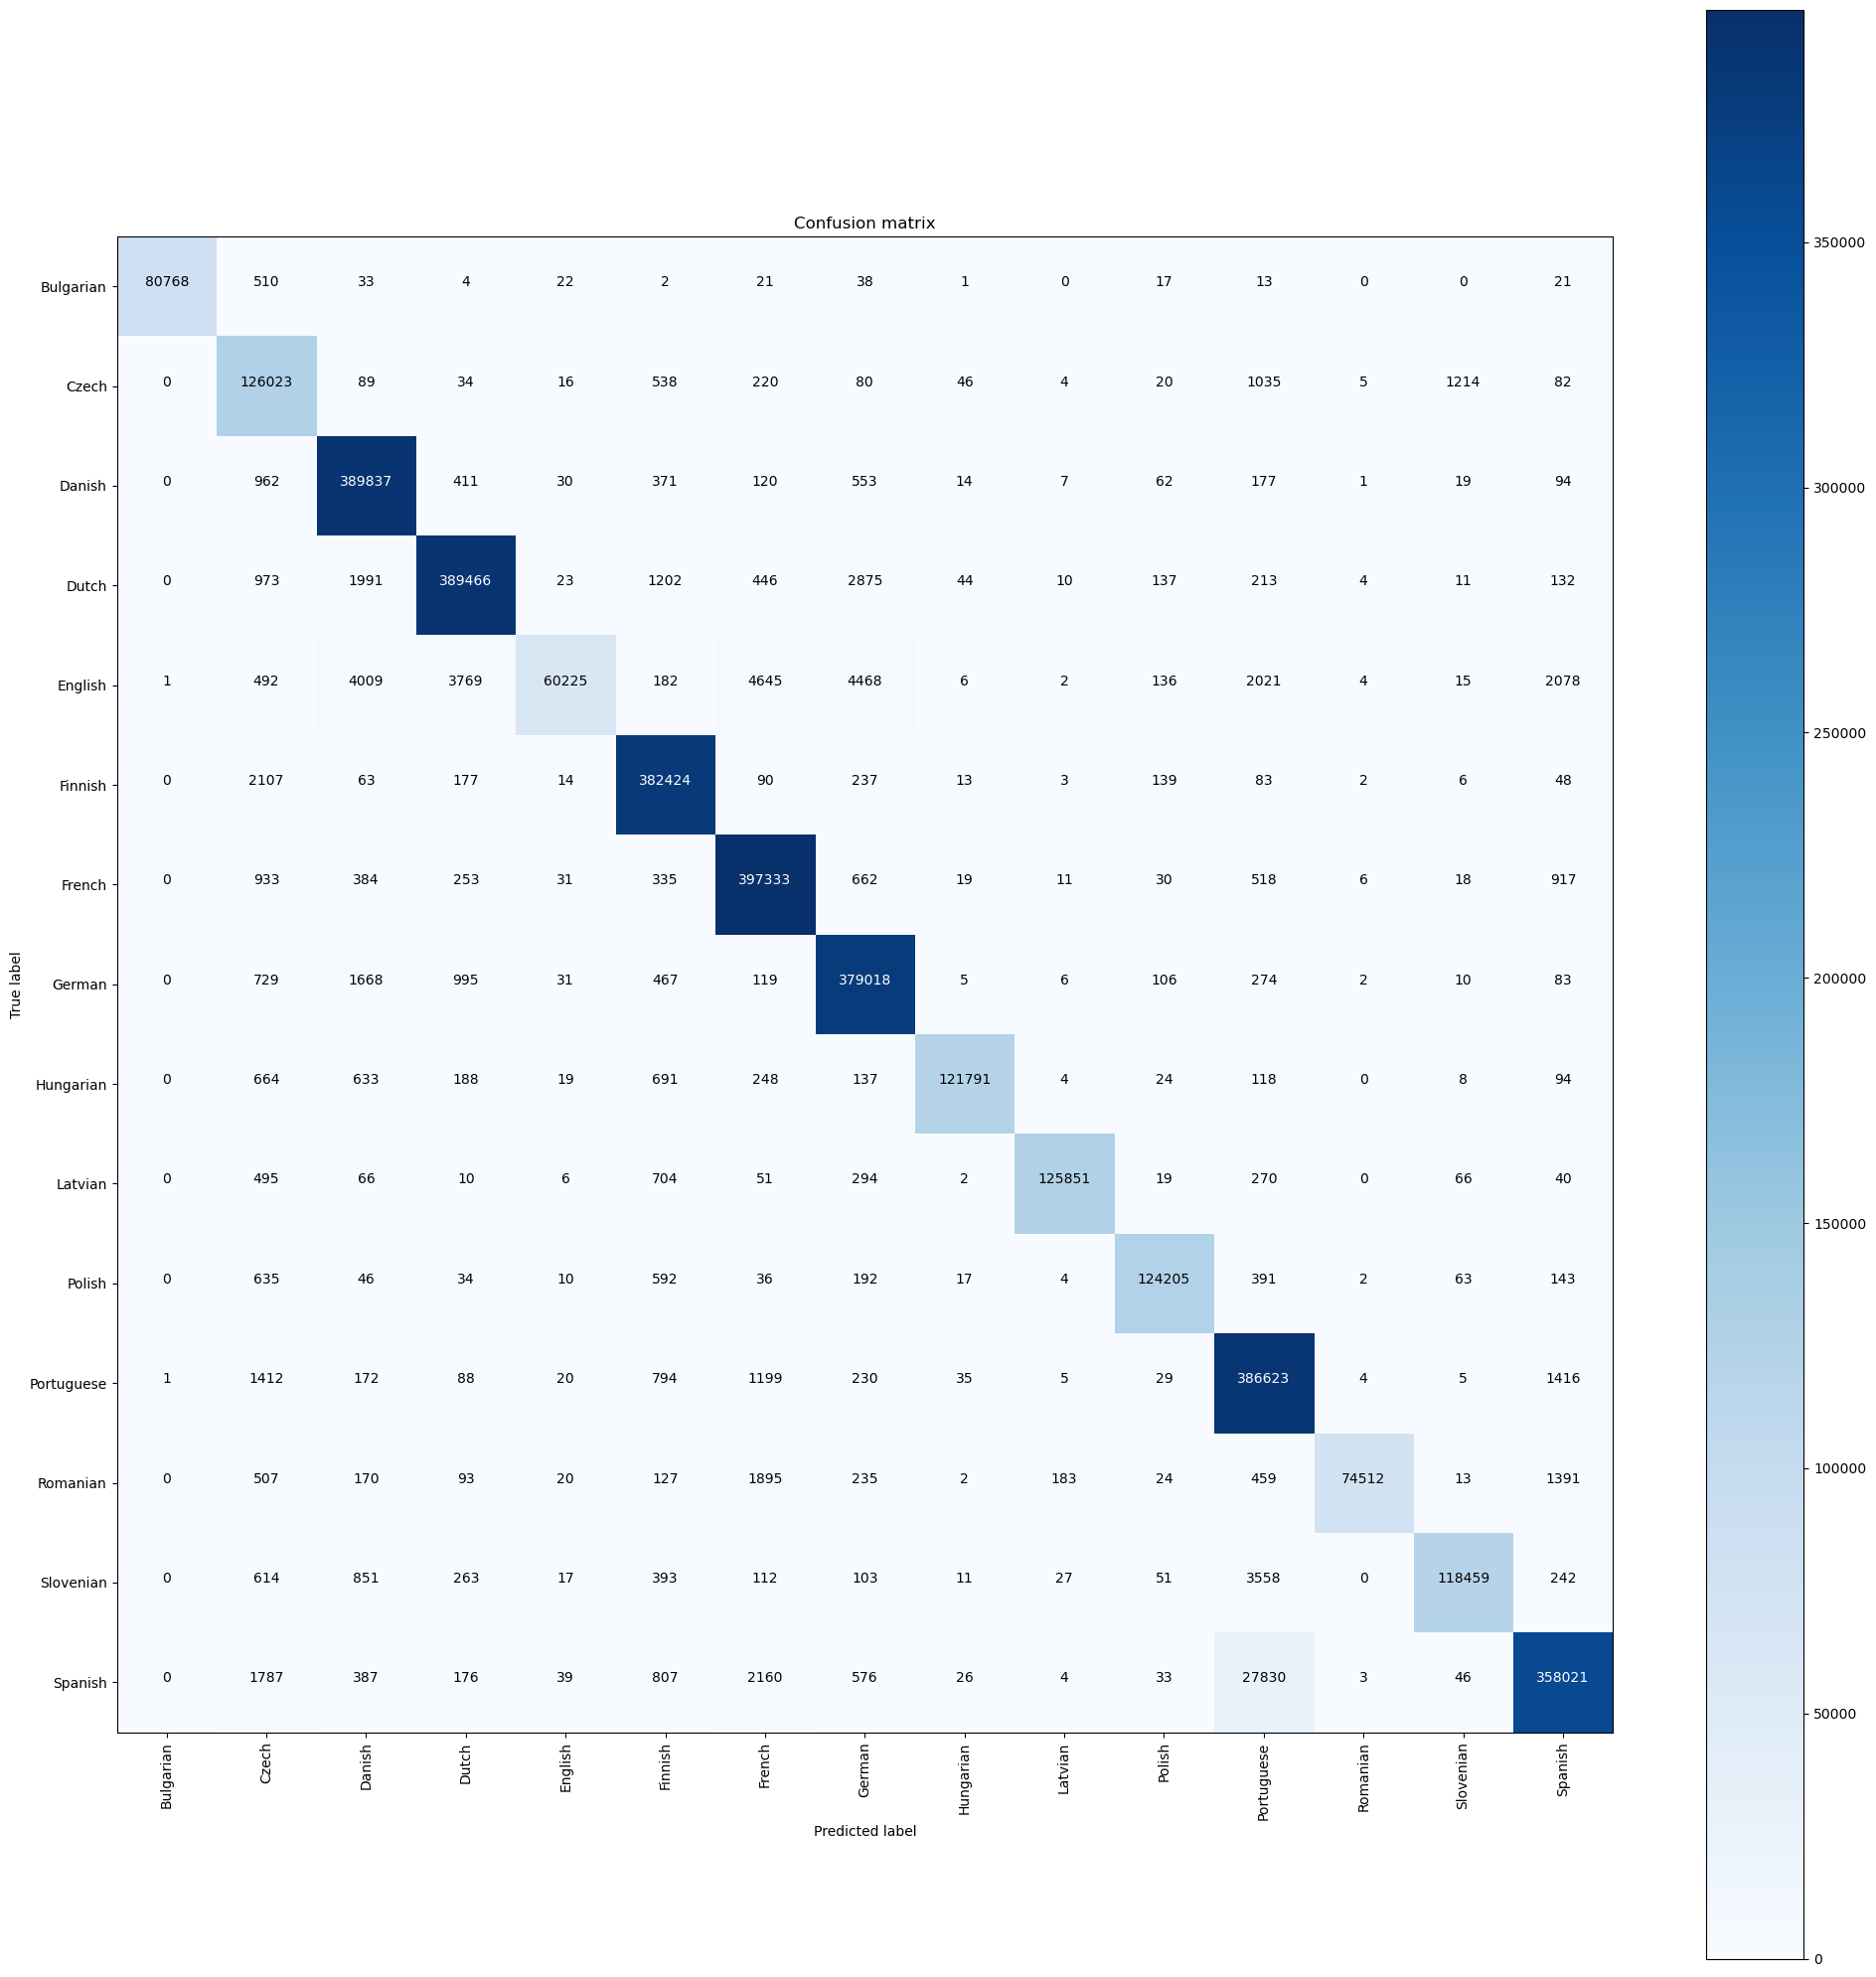

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
import joblib 

# Import scikit-learn modules
from sklearn import feature_extraction
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn import pipeline
from sklearn.model_selection import train_test_split
from sklearn import metrics

# === 1. Load Clean Data ===
print("Loading clean data from Parquet file...")
try:
    # Load the preprocessed data from the Parquet file
    df = pd.read_parquet('clean_europarl_data.parquet')
    print(f"Clean data loaded! ({len(df)} rows)")
except FileNotFoundError:
    print("ERROR: 'clean_europarl_data.parquet' not found.")
    print("Please make sure the file is in the same directory as your notebook.")
    # Create an empty DataFrame to avoid further errors
    df = pd.DataFrame(columns=['Text', 'Language'])


# === 2. Splitting the dataset ===
if not df.empty:
    print("\nSplitting the dataset...")
    # Define independent (X) and dependent (y) variables
    x = df.iloc[:, 0] 
    y = df.iloc[:, 1] 

    # Split the full dataset into training (80%) and testing (20%) sets
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
    
    print(f"Total samples: {len(df)}")
    print(f"Training samples: {len(x_train)}")
    print(f"Testing samples: {len(x_test)}")


    # === 3. Model 1: MultinomialNB Test (on a small sample) ===
    print("\nRunning quick test with MultinomialNB on a small sample...")
    
    # Create a smaller sample for a quick test
    sample_x_train = x_train.iloc[:5000]
    sample_y_train = y_train.iloc[:5000]
    sample_x_test = x_test.iloc[:1000]
    sample_y_test = y_test.iloc[:1000]

    # Define a TF-IDF Vectorizer for character n-grams (1 to 3)
    vectorizer_mnb = feature_extraction.text.TfidfVectorizer(
        ngram_range=(1, 3), analyzer='char', max_features=50000
    )
    
    # Create a pipeline with the vectorizer and a Multinomial Naive Bayes classifier
    pipe_mnb = pipeline.Pipeline([
        ('vectorizer', vectorizer_mnb),
        ('clf', MultinomialNB(alpha=0.1))
    ])
    
    # Train the test model on the sample data
    pipe_mnb.fit(sample_x_train, sample_y_train)
    # Make predictions on the sample test set
    mnb_predicted = pipe_mnb.predict(sample_x_test)
    # Calculate and print the accuracy
    mnb_acc = metrics.accuracy_score(sample_y_test, mnb_predicted) * 100
    print(f"MultinomialNB quick test accuracy: {mnb_acc:.2f}%\n")


    # === 4. Model 2: LogisticRegression (MAIN MODEL) ===
    print("\nTraining main LogisticRegression model...")
    
    # Define a TF-IDF Vectorizer (char n-grams 1-2, 10k features)
    vectorizer_lr = feature_extraction.text.TfidfVectorizer(
        ngram_range=(1, 2),
        analyzer='char',
        max_features=10000 
    )
    
    # Create a pipeline with the vectorizer and Logistic Regression
    pipe_lr = pipeline.Pipeline([
        ('vectorizer', vectorizer_lr),
        ('lr_clf', LogisticRegression(
            solver='liblinear', 
            max_iter=100, 
            verbose=1 
        ))
    ])

    # Fit the pipeline on a small sample (1000 rows) of the training set
    print("Fitting pipeline on a 1000-row sample of the training set...")
    pipe_lr.fit(x_train[:1000], y_train[:1000])
    print("Main model training complete.\n")


    # === 5. Evaluate the Main Model ===
    print("\nEvaluating main model on the FULL test set...")
    # Make predictions on the full test set
    lr_predicted = pipe_lr.predict(x_test)
    # Calculate and print the accuracy
    lr_acc = (metrics.accuracy_score(y_test, lr_predicted)) * 100
    print(f'LogisticRegression Accuracy (FULL test set): {lr_acc:.2f} %')


    # === 6. Confusion Matrix ===
    
    # Helper function to plot the confusion matrix
    def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
        plt.imshow(cm, interpolation='nearest', cmap=cmap)
        plt.title(title)
        plt.colorbar()
        tick_marks = np.arange(len(classes))
        plt.xticks(tick_marks, classes, rotation=90)
        plt.yticks(tick_marks, classes)
        
        if normalize:
            cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        thresh = cm.max() / 2.
        # Add text labels to each cell
        for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
            plt.text(j, i, f"{cm[i, j]:.0f}", 
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        
        plt.tight_layout()
        plt.ylabel('True label')
        plt.xlabel('Predicted label')

    print("\nCalculating and plotting confusion matrix...")
    # Generate the confusion matrix
    matrix = metrics.confusion_matrix(y_test, lr_predicted)
    
    # Get sorted labels to ensure correct plot labels
    sorted_labels = sorted(y.unique())

    # Create and save the plot
    plt.figure(figsize=(20, 20))
    plot_confusion_matrix(matrix, classes=sorted_labels)
    plt.savefig("confusion_matrix_full_model.png")
    print("Confusion matrix saved to 'confusion_matrix_full_model.png'\n")


    # === 7. Save the Trained Model ===
    print("\nSaving the main (pipe_lr) model to 'language_detection_model.joblib'...")
    # Use joblib to serialize and save the pipeline
    joblib.dump(pipe_lr, "language_detection_model.joblib")
    print("Model saved successfully!")

else:
    print("\nDataFrame 'df' is empty. Halting execution.")
    print("Please run the data cleaning and parquet saving steps first.")